In [1]:
# from LadrunoGraphStyle import set_default_plot_params, main_colors
# set_default_plot_params()

In [2]:
from fem import (
    # Core
    Material,
    # Sections
    Membrane,
    # Gmsh tools
    GMSHtools,
    # FEM builders
    build_elements,
    # Visualization — Gmsh
    add_element_data_view, add_node_data_view, compute_nodal_average,
    # Plotting — matplotlib
    plot_mesh, plot_field_2d, plot_deformed, plot_loads_2d, plot_gmsh_mesh,
    # Elements
    CST, LST, Quad4, Quad9,
    # Units
    kgf, tf, kN, MPa, GPa, kg, g, cm, m, mm,
    # Parameters
    globalParameters,
)

import os
import numpy as np
import matplotlib.pyplot as plt
import gmsh

np.set_printoptions(suppress=True, precision=6, linewidth=400)


  FEM -- Finite Element Method for Structural Analysis
  Based on the course by Prof. José Abell

  Version 1.1.0                        © 2026 All Rights Reserved

  Repository  :  https://github.com/ppalacios92/FEM
  Web Book    :  https://books.nmorabowen.com/books/fem

  Patricio Palacios B.    |    Nicolas Mora Bowen

  ********* (>'-')> Ladruño4ever  *********



In [3]:
globalParameters['nDoF'] = 2
globalParameters['nDIM'] = 2

In [4]:
# General model parameters

output_path = os.getcwd()
mesh_name = 'Cantiliverbeam'
output_file = os.path.join(output_path, mesh_name + '.msh')

if not os.path.exists(output_path):
    os.makedirs(output_path)

In [5]:
# gmsh.initialize()
# gmsh.model.add(mesh_name)

# # Points
# p1 = gmsh.model.geo.addPoint(0,    0,    0)
# p2 = gmsh.model.geo.addPoint(0,    1600, 0)
# p3 = gmsh.model.geo.addPoint(600,  1600, 0)
# p4 = gmsh.model.geo.addPoint(605,  1400, 0)
# p5 = gmsh.model.geo.addPoint(610,  1600, 0)
# p6 = gmsh.model.geo.addPoint(2800, 1600, 0)
# p7 = gmsh.model.geo.addPoint(2800, 600,  0)
# p8 = gmsh.model.geo.addPoint(1,    1600, 0)

# # Lines
# l1 = gmsh.model.geo.addLine(p1, p7)
# l2 = gmsh.model.geo.addLine(p7, p6)
# l3 = gmsh.model.geo.addLine(p6, p5)
# l4 = gmsh.model.geo.addLine(p5, p4)
# l5 = gmsh.model.geo.addLine(p4, p3)
# l6 = gmsh.model.geo.addLine(p3, p8)
# l7 = gmsh.model.geo.addLine(p8, p2)
# l8 = gmsh.model.geo.addLine(p2, p1)

# # Surface
# c1 = gmsh.model.geo.addCurveLoop([l8, l1, l2, l3, l4, l5, l6, l7])
# s1 = gmsh.model.geo.addPlaneSurface([c1])

# gmsh.model.geo.synchronize()

# # Transfinite curves
# gmsh.model.mesh.setTransfiniteCurve(l8, 16)
# gmsh.model.mesh.setTransfiniteCurve(l1, 25)
# gmsh.model.mesh.setTransfiniteCurve(l2, 10)
# gmsh.model.mesh.setTransfiniteCurve(l3, 20)
# gmsh.model.mesh.setTransfiniteCurve(l6,  6)
# gmsh.model.mesh.setTransfiniteCurve(l5,  4)
# gmsh.model.mesh.setTransfiniteCurve(l4,  4)
# gmsh.model.mesh.setTransfiniteCurve(l7,  2)

# # Physical groups
# gmsh.model.addPhysicalGroup(1, [l8],      9)
# gmsh.model.setPhysicalName( 1,  9, 'Empotrado')
# gmsh.model.addPhysicalGroup(1, [l6, l3], 10)
# gmsh.model.setPhysicalName( 1, 10, 'Carga')
# gmsh.model.addPhysicalGroup(2, [s1],     11)
# gmsh.model.setPhysicalName( 2, 11, 'Con')

# gmsh.model.geo.synchronize()


# def all_quads():
#     gmsh.model.geo.synchronize()
#     gmsh.option.setNumber("Mesh.RecombineAll", 1)
#     gmsh.option.setNumber("Mesh.Algorithm", 8)
#     gmsh.option.setNumber("Mesh.RecombinationAlgorithm", 2)
#     gmsh.option.setNumber("Mesh.Smoothing", 100)
#     gmsh.option.setNumber("Mesh.ElementOrder", 1)

# # all_quads()


In [6]:
gmsh.initialize()
gmsh.model.add(mesh_name)

lc = 100

# Points
p1 = gmsh.model.geo.addPoint(0,    0,    0, lc)
p2 = gmsh.model.geo.addPoint(0,    1600, 0, lc)
p3 = gmsh.model.geo.addPoint(600,  1600, 0, lc)
p4 = gmsh.model.geo.addPoint(605,  1400, 0, lc)
p5 = gmsh.model.geo.addPoint(610,  1600, 0, lc)
p6 = gmsh.model.geo.addPoint(2800, 1600, 0, lc)
p7 = gmsh.model.geo.addPoint(2800, 600,  0, lc)
p8 = gmsh.model.geo.addPoint(1,    1600, 0, lc)

# Lines
l1 = gmsh.model.geo.addLine(p1, p7)
l2 = gmsh.model.geo.addLine(p7, p6)
l3 = gmsh.model.geo.addLine(p6, p5)
l4 = gmsh.model.geo.addLine(p5, p4)
l5 = gmsh.model.geo.addLine(p4, p3)
l6 = gmsh.model.geo.addLine(p3, p8)
l7 = gmsh.model.geo.addLine(p8, p2)
l8 = gmsh.model.geo.addLine(p2, p1)

# Surface
c1 = gmsh.model.geo.addCurveLoop([l8, l1, l2, l3, l4, l5, l6, l7])
s1 = gmsh.model.geo.addPlaneSurface([c1])

gmsh.model.geo.synchronize()

# Physical groups
gmsh.model.addPhysicalGroup(1, [l8],      9)
gmsh.model.setPhysicalName( 1,  9, 'Empotrado')
gmsh.model.addPhysicalGroup(1, [l6, l3], 10)
gmsh.model.setPhysicalName( 1, 10, 'Carga')
gmsh.model.addPhysicalGroup(2, [s1],     11)
gmsh.model.setPhysicalName( 2, 11, 'Con')

gmsh.model.geo.synchronize()

def all_quads():
    gmsh.model.geo.synchronize()
    gmsh.option.setNumber("Mesh.RecombineAll", 1)
    gmsh.option.setNumber("Mesh.Algorithm", 8)
    gmsh.option.setNumber("Mesh.RecombinationAlgorithm", 2)
    gmsh.option.setNumber("Mesh.Smoothing", 100)
    gmsh.option.setNumber("Mesh.ElementOrder", 1)

# all_quads()
# gmsh.option.setNumber("Mesh.ElementOrder", 2)

In [7]:
# Generate the mesh
gmsh.model.mesh.generate()
# Save mesh to disk
gmsh.write(output_file)
# Open GMSH GUI
gmsh.fltk.run()
# Write mesh file again (redundant)
v = gmsh.write(output_file)
# Close GMSH instance
gmsh.finalize()

In [8]:
fcp = 40*MPa
fct = 0.35*np.sqrt(fcp/MPa)*MPa
thickness = 1*m
rho = 2500 * kg/m**3

qload = (0.50*kN/mm)/(1*m)
# qload = (0.5*tf/m)/(1*m)

#Constants
E_conc = 4700*np.sqrt(fcp/MPa)*MPa
nu_conc = 0.17

In [9]:
# Definimos el material
Concrete=Material(name='Concrete',
             E=E_conc,
             nu=nu_conc,
             rho=rho*0)

# Definimos una seccion de la membrana
Cantiliverbeam=Membrane(name='Cantiliverbeam',
                thickness=thickness,
                material=Concrete)

section_dictionary={11:Cantiliverbeam,
                        }


restrain_dictionary={9:['r', 'r']}



load_dictionary = {
    10:   {'value': qload, 'direction': '-y'},   # line load  [N/mm]
    # 258: {'value': -30,   'direction': 'y'},     # point load [N]
}


In [10]:
# read mesh — node_map and system_nDof auto-generated
mesh = GMSHtools(output_file)

  MESH SUMMARY

  === NODES ===  (488 total — showing first 3)
     Tag              x              y              z
--------------------------------------------------------------------------------
       1         0.0000         0.0000         0.0000
       2         0.0000      1600.0000         0.0000
       3       600.0000      1600.0000         0.0000
--------------------------------------------------------------------------------

  === PHYSICAL GROUPS ===  (3 total)
      ID    Dim   Name
--------------------------------------------------------------------------------
       9      1   'Empotrado'
      10      1   'Carga'
      11      2   'Con'
--------------------------------------------------------------------------------

  === ELEMENTS ===  (3 groups)
      ID    Dim     Type   Nodes/el   N elements   Name
--------------------------------------------------------------------------------
       9      1        1          2           16   'Empotrado'
      10      1        1

In [11]:
# Initialize nodes and apply Dirichlet (restraints) and Neumann (nodal loads) boundary conditions.
mesh.apply_boundary_conditions(restrain_dictionary, load_dictionary, section_dictionary, verbose=True)


  === BOUNDARY CONDITIONS ===
  Nodes created  : 488
  system_nDof    : 976

  --- Restrained nodes ---
     Tag              x              y   Restraints
--------------------------------------------------------------------------------
       1         0.0000         0.0000   ['r', 'r']
       2         0.0000      1600.0000   ['r', 'r']
      74         0.0000      1500.0000   ['r', 'r']
      75         0.0000      1400.0000   ['r', 'r']
      76         0.0000      1300.0000   ['r', 'r']
      77         0.0000      1200.0000   ['r', 'r']
      78         0.0000      1100.0000   ['r', 'r']
      79         0.0000      1000.0000   ['r', 'r']
      80         0.0000       900.0000   ['r', 'r']
      81         0.0000       800.0000   ['r', 'r']
      82         0.0000       700.0000   ['r', 'r']
      83         0.0000       600.0000   ['r', 'r']
      84         0.0000       500.0000   ['r', 'r']
      85         0.0000       400.0000   ['r', 'r']
      86         0.0000       300.

In [12]:
system_nDof = mesh.system_nDof
node_map = mesh.node_map

In [13]:
# Map number of nodes per element to element class
element_map = {
    3: CST,         # 3-node triangles
    4: Quad4,       # 4-node quadrilaterals
    6: LST,         # 6-node triangles
    9: Quad9,       # 9-node quadrilaterals
}

# build FEM elements
elements = build_elements(
    mesh               = mesh,
    node_map           = mesh.node_map,
    section_dictionary = section_dictionary,
    element_class_map  = element_map,
    load_dictionary    = load_dictionary,
    type               = 'planeStress',
    sampling_points    = 3,
    eval_points        = [0, 0],
)

In [14]:
# # build lumped nodal force vector
# F_nodal = mesh.build_load_vector(load_dictionary)

# # assemble to global vector
# F_load = np.zeros(mesh.system_nDof)
# for tag, f_vec in F_nodal.items():
#     if tag in mesh.node_map:
#         F_load[mesh.node_map[tag].idx[:len(f_vec)]] += f_vec
# F_load[np.abs(F_load) < 1e-4] = 0.0

In [15]:
# assemble consistent load vector
F_load = np.zeros(mesh.system_nDof)
for node in mesh.node_map.values():
    F_load[node.idx] += node.nodalLoad  
for elem in elements:
    F_load[elem.idx] += elem.F_fe_global 
F_load[np.abs(F_load) < 1e-4] = 0.0

In [16]:
# # %matplotlib widge
# plot_gmsh_mesh(mesh,
#                show_node_labels   = False,
#                show_element_labels= False,
#                show_node_points   = True,
#             #    view_3d            = True,   elev= 45, azim= -45,
#                figsize            = (12, 8))

In [17]:
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve

# Assembly
K = lil_matrix((system_nDof, system_nDof))
for element in elements:
    for i_local, i_global in enumerate(element.idx):
        for j_local, j_global in enumerate(element.idx):
            K[i_global, j_global] += element.kg[i_local, j_local]
K = K.tocsr()

# Force vector
F = F_load.copy()

# DOF classification
dof_flags       = np.concatenate([node.restrain for node in node_map.values()])
free_dofs       = np.where(dof_flags == 'f')[0]
restrained_dofs = np.where(dof_flags == 'r')[0]

# Partitioning
Kff = K[free_dofs[:, None], free_dofs]
Kfr = K[free_dofs[:, None], restrained_dofs]
Krf = K[restrained_dofs[:, None], free_dofs]
Krr = K[restrained_dofs[:, None], restrained_dofs]

# Solution
ur = np.zeros(len(restrained_dofs))
uf = spsolve(Kff, F[free_dofs] - Kfr @ ur)

u = np.zeros(system_nDof)
u[free_dofs]       = uf
u[restrained_dofs] = ur

# Reactions
Rr = Krf @ uf + Krr @ ur
R  = np.zeros(system_nDof)
R[restrained_dofs] = Rr

In [18]:
def get_node(node_map, u, tag=None, x=None, y=None):
    """
    Returns a node by tag or by closest position and prints its displacements.
    Provide either tag or (x, y), not both.
    """
    if tag is not None:
        node = node_map[tag]
    else:
        best_tag  = None
        best_dist = np.inf
        for t, n in node_map.items():
            dist = np.linalg.norm(n.coordinates - np.array([x, y]))
            if dist < best_dist:
                best_dist = dist
                best_tag  = t
        node = node_map[best_tag]

    d = u[node.idx]
    print(f"Node {node.name} at {node.coordinates}:  ux={d[0]:+.6f}  uy={d[1]:+.6f}")
    return node

In [19]:
# By tag
node = get_node(node_map, u , tag=3)
# By position
node = get_node(node_map, u, x=1000, y=500)

Node 3 at [ 600. 1600.]:  ux=+0.054599  uy=-0.063136
Node 346 at [971.709225 513.697802]:  ux=-0.052397  uy=-0.148744


In [20]:
# Reactions per node
for node in node_map.values():
    if any(r == 'r' for r in node.restrain):
        r = R[node.idx]
        print(f"Node {node.name}:  Rx={r[0]:+.6f}  Ry={r[1]:+.6f}")

# Equilibrium check
total_applied_x  = np.sum(F[0::2])
total_applied_y  = np.sum(F[1::2])
total_reaction_x = np.sum(R[0::2])
total_reaction_y = np.sum(R[1::2])
print('--' * 50)
print(f"Applied X:  {total_applied_x:+.4f}   Reaction X: {total_reaction_x:+.4f}   Balance: {total_applied_x + total_reaction_x:.4e}")
print(f"Applied Y:  {total_applied_y:+.4f}   Reaction Y: {total_reaction_y:+.4f}   Balance: {total_applied_y + total_reaction_y:.4e}")

Node 1:  Rx=+229868.883444  Ry=+83645.137701
Node 2:  Rx=-350198.680269  Ry=+113698.669426
Node 74:  Rx=-402904.322997  Ry=+118125.339493
Node 75:  Rx=-301929.592487  Ry=+109813.022403
Node 76:  Rx=-246366.269134  Ry=+100828.600359
Node 77:  Rx=-196180.547244  Ry=+84361.047631
Node 78:  Rx=-148445.287375  Ry=+77136.989753
Node 79:  Rx=-95215.934568  Ry=+69360.781524
Node 80:  Rx=-43348.362556  Ry=+65772.849909
Node 81:  Rx=+12619.999411  Ry=+62038.292612
Node 82:  Rx=+65495.361671  Ry=+64489.720746
Node 83:  Rx=+117240.864013  Ry=+60906.448561
Node 84:  Rx=+169164.410147  Ry=+68189.786688
Node 85:  Rx=+222337.660860  Ry=+70302.698295
Node 86:  Rx=+272818.887127  Ry=+75623.371137
Node 87:  Rx=+324586.362965  Ry=+85368.203905
Node 88:  Rx=+370456.566991  Ry=+84839.039855
----------------------------------------------------------------------------------------------------
Applied X:  +0.0000   Reaction X: -0.0000   Balance: -2.1188e-08
Applied Y:  -1394500.0000   Reaction Y: +1394500.0000 

In [21]:
# Check if any restrained node has load
for node in node_map.values():
    if any(r == 'r' for r in node.restrain):
        fy = F_load[node.idx[1]]
        if abs(fy) > 0:
            print(f"Node {node.name} at {node.coordinates}: restrained but has Fy={fy:+.4f}")

In [22]:
n_nodes    = len(node_map)
n_elements = len(elements)

# Prepare displacement, force and reaction arrays (3D format for Gmsh)
u_3d = np.zeros((n_nodes, 3))
F_3d = np.zeros((n_nodes, 3))
R_3d = np.zeros((n_nodes, 3))

for i, node in enumerate(node_map.values()):
    u_3d[i, 0] = u[node.idx[0]]
    u_3d[i, 1] = u[node.idx[1]]
    F_3d[i, 0] = F[node.idx[0]]
    F_3d[i, 1] = F[node.idx[1]]
    R_3d[i, 0] = R[node.idx[0]]
    R_3d[i, 1] = R[node.idx[1]]

# Node tags for Gmsh
node_tags = np.array([node.name for node in node_map.values()])

# Stress, strain and Von Mises
sigma_gmsh             = np.zeros((n_elements, 3))
epsilon_gmsh           = np.zeros((n_elements, 3))
sigma_principal_gmsh   = np.zeros((n_elements, 2))
epsilon_principal_gmsh = np.zeros((n_elements, 2))
von_mises_gmsh         = np.zeros(n_elements)
element_tags_list      = []

for i, element in enumerate(elements):
    results = element.get_results(u)
    sigma   = results['stress'].flatten()
    epsilon = results['strain'].flatten()

    sigma_gmsh[i, :]             = sigma
    epsilon_gmsh[i, :]           = epsilon
    sigma_principal_gmsh[i, :]   = results['principal_stress'].flatten()
    epsilon_principal_gmsh[i, :] = results['principal_strain'].flatten()

    sxx, syy, sxy     = sigma
    von_mises_gmsh[i] = np.sqrt(sxx**2 - sxx*syy + syy**2)
    element_tags_list.append(element.element_tag)

In [23]:

# VISUALIZE RESULTS IN GMSH


gmsh.initialize()
gmsh.open(output_file)

# Node tags already computed above
# node_tags = np.array([node.name for node in nodes_list])

# --- Nodal vector fields ---
# VectorType options:
# 1 → Line segments (simple lines)
# 2 → Arrows
# 3 → Pyramids
# 4 → 3D arrows
# 5 → Displacement (visually deforms mesh)
# 6 → Displacement with deformation

# view_disp_vec = add_node_data_view("Disp Vector", 
#                                     node_tags, 
#                                     u_3d, 
#                                     visible=False)
# u_mag = np.linalg.norm(u_3d, axis=1)


view_disp  = add_node_data_view("Displacements",
                   node_tags, 
                   u_3d,
                #    deformed_view=view_disp_vec, 
                   vector_type=5,
                   factor=2)

add_node_data_view("Applied Loads",
                   node_tags,
                   F_3d,
                   arrow_size_max=60,
                   arrow_size_min=20)

add_node_data_view("Reactions",
                   node_tags,
                   R_3d)

2

In [24]:
# Hide surface faces for better visualization
gmsh.option.setNumber("Mesh.SurfaceFaces", 0)

# --- Element-based stress fields ---
add_element_data_view("Stress Sxx", 
                      element_tags_list, 
                      sigma_gmsh[:, 0])

add_element_data_view("Stress Syy", 
                      element_tags_list,
                        sigma_gmsh[:, 1])

add_element_data_view("Stress Sxy", 
                      element_tags_list, 
                      sigma_gmsh[:, 2])

# --- Element-based strain fields ---
add_element_data_view("Strain Exx", 
                      element_tags_list, 
                      epsilon_gmsh[:, 0])

add_element_data_view("Strain Eyy", 
                      element_tags_list, 
                      epsilon_gmsh[:, 1])

add_element_data_view("Strain Exy",
                      element_tags_list, 
                      epsilon_gmsh[:, 2])

8

In [25]:
# --- Principal stresses ---
add_element_data_view("Principal Stress S1", 
                      element_tags_list, 
                      sigma_principal_gmsh[:, 0])

add_element_data_view("Principal Stress S2", 
                      element_tags_list, 
                      sigma_principal_gmsh[:, 1])

# --- Principal strains ---
add_element_data_view("Principal Strain E1", 
                      element_tags_list,
                        epsilon_principal_gmsh[:, 0])

add_element_data_view("Principal Strain E2", 
                      element_tags_list,
                        epsilon_principal_gmsh[:, 1])

12

In [26]:
# --- Von Mises stress ---
add_element_data_view("Von Mises Stress", 
                      element_tags_list, 
                      von_mises_gmsh)

13

In [27]:
# --- Nodal averaged stress fields ---
sxx_nodal = compute_nodal_average(  mesh, 
                                    element_tags_list, 
                                    sigma_gmsh[:, 0])
add_node_data_view("Sxx Nodal Averaged",    
                    node_tags, sxx_nodal,deformed_view=view_disp)

# -----------------
syy_nodal = compute_nodal_average(  mesh, 
                                    element_tags_list, 
                                    sigma_gmsh[:, 1])
add_node_data_view("Syy Nodal Averaged",    
                    node_tags, syy_nodal,deformed_view=view_disp)

# -----------------
sxy_nodal = compute_nodal_average(  mesh, 
                                    element_tags_list, 
                                    sigma_gmsh[:, 2])
add_node_data_view("Sxy Nodal Averaged",    
                    node_tags, sxy_nodal,deformed_view=view_disp)

# -----------------
s1_nodal = compute_nodal_average(   mesh, 
                                    element_tags_list, 
                                    sigma_principal_gmsh[:, 0])
add_node_data_view("Principal Stress S1 Nodal Averaged", 
                    node_tags, s1_nodal,deformed_view=view_disp)

# -----------------
s2_nodal = compute_nodal_average(   mesh, 
                                    element_tags_list, 
                                    sigma_principal_gmsh[:, 1])
add_node_data_view("Principal Stress S2 Nodal Averaged", 
                    node_tags, s2_nodal,deformed_view=view_disp)

# -----------------
vm_nodal = compute_nodal_average(mesh, 
                                 element_tags_list, 
                                 von_mises_gmsh)
add_node_data_view("Von Mises Nodal Averaged",
                   node_tags, vm_nodal,deformed_view=view_disp)

# -----------------
exx_nodal = compute_nodal_average(mesh, 
                                element_tags_list, 
                                epsilon_gmsh[:, 0])
add_node_data_view("Strain Exx Averaged", 
                    node_tags, exx_nodal)

# -----------------
# Open Gmsh GUI
gmsh.fltk.run()
gmsh.finalize()

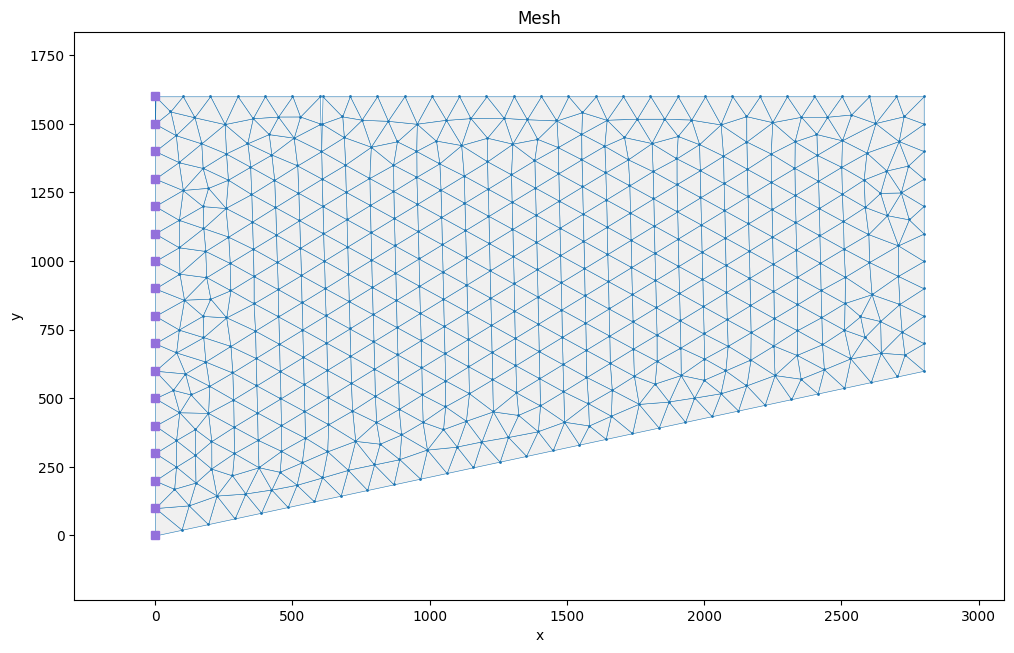

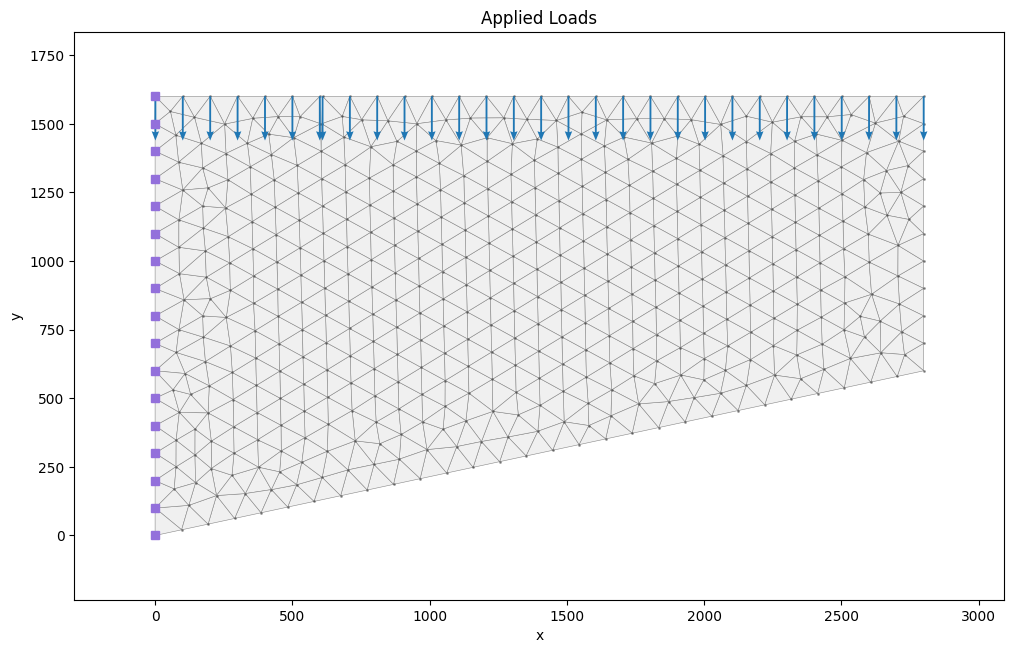

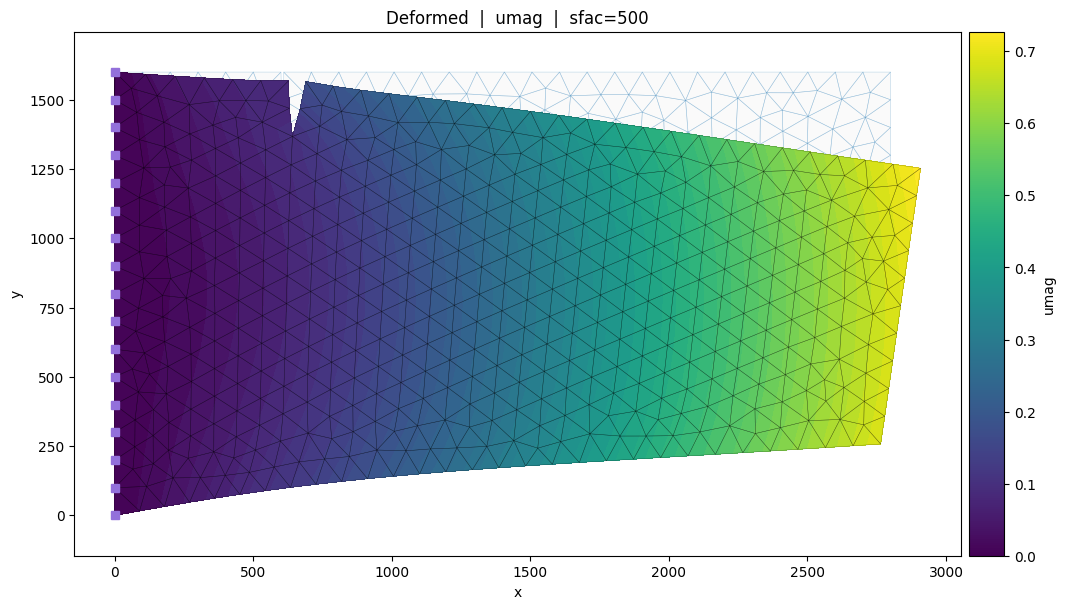

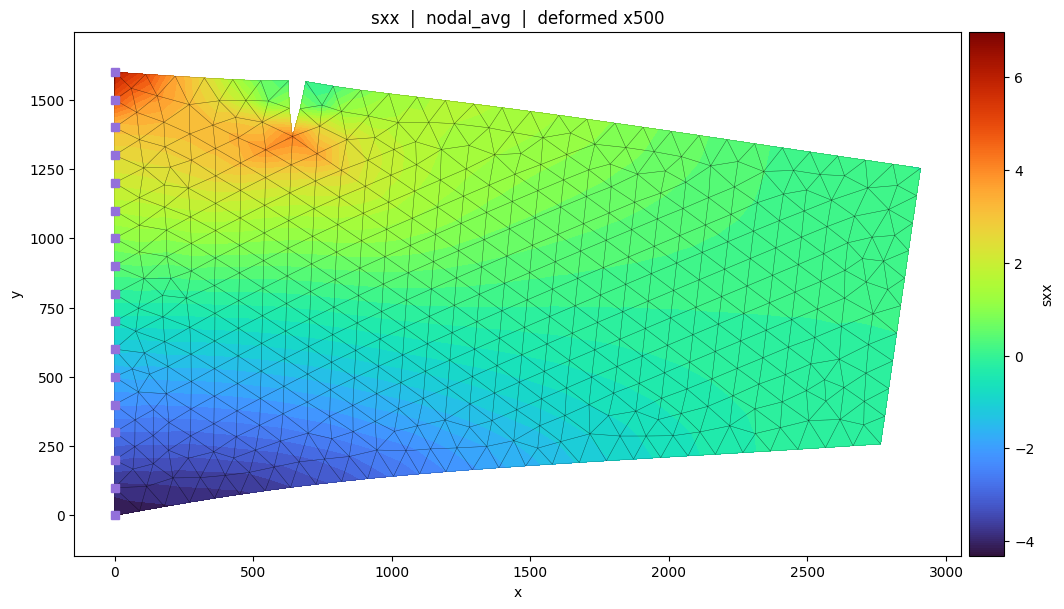

In [28]:
# Mesh
plot_mesh(
    nodes               = node_map.values(),
    elements            = elements,
    show_node_labels    = False,
    show_element_labels = False,
    show_supports       = True,
    show_element_edges  = True,
    show_node_points    = True,
    figsize             = (12, 12),
    ax                  = None,
    save                = None,
)

# Loads
plot_loads_2d(
    nodes               = node_map.values(),
    elements            = elements,
    F_load              = F_load,
    show_element_edges  = True,
    show_node_points    = True,
    show_supports       = True,
    figsize             = (12, 12),
    ax                  = None,
    save                = None,
)

# Deformed
plot_deformed(
    nodes               = node_map.values(),
    elements            = elements,
    u                   = u,
    component           = 'umag',   # 'ux', 'uy', 'umag'
    sfac                = 500,
    cmap                = 'viridis',
    limit               = None,
    show_element_edges  = True,
    show_node_points    = False,
    show_supports       = True,
    figsize             = (12, 12),
    ax                  = None,
    save                = None,
)

# Stress or Strain Field
plot_field_2d(
    nodes               = node_map.values(),
    elements            = elements,
    u                   = u,
    component           = 'sxx',       # 'sxx','syy','sxy','vmis','s1','s2','exx','eyy','exy','e1','e2'
    result_type         = 'nodal_avg', # 'nodal_avg' or 'element'
    deformed            = True,
    sfac                = 500,
    limit               = None,
    cmap                = 'turbo',
    show_element_edges  = True,
    show_node_points    = False,
    show_supports       = True,
    figsize             = (12, 12),
    ax                  = None,
    save                = None,
)